In [1]:
# LOAD Packages 
import uproot
import pandas as pd
import numpy as np
import awkward as ak
!pip install awkward_pandas
import matplotlib
from mpl_toolkits.mplot3d import Axes3D
#matplotlib.rcParams.update(matplotlib.rcParamsDefault)
#matplotlib.rcParams['text.usetex'] = True
import matplotlib.pyplot as plt
import os
import math
import csv
#import seaborn as sns
import sympy as smp
import sympy.stats
import json
import h5py
import sys
#from scipy import stats,signal,ndimage,special,fft
#from scipy.optimize import curve_fit
#from scipy.integrate import quad
#from mpl_toolkits.axes_grid1 import make_axes_locatable
#!pip install plotly
import plotly
import plotly.graph_objects as go


Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
# Get shower data function 
def get_shower_data(sim_h5, event_id):

    parse_var='event_id'
    seg_var='segments'     

    traj_spill_mask = sim_h5['trajectories'][:][parse_var]==event_id
    seg_spill_mask = sim_h5[seg_var][:][parse_var]==event_id
    event_mask = sim_h5['events'][:][parse_var]==event_id

    traj = sim_h5['trajectories'][traj_spill_mask]
    seg = sim_h5[seg_var][seg_spill_mask]
    event = sim_h5['events'][event_mask]

    return traj, seg, event

2974.114 0
9821.458 1
5118.0024 2
13097.452 3
5115.5547 4
12529.871 5
12373.214 6
5774.0576 7
5534.604 8
4835.6616 9
1107.3665 10
13839.625 11
13851.216 12
11925.486 13
8298.23 14
9203.66 15
4878.1436 16
2285.1096 17
8566.302 18
8767.317 19
4142.7124 20
5349.6875 21
6500.152 22
10399.428 23
9114.361 24
7757.699 25
2738.1191 26
6559.11 27
8012.7534 28
646.8072 29
10746.466 30
9936.526 31
11352.387 32
7672.418 33
12682.055 34
3492.7288 35
8799.567 36
4250.521 37
13337.884 38
13075.944 39
1390.966 40
3245.4668 41
1900.341 42
3706.743 43
10683.314 44
3029.1963 45
3619.8735 46
1746.3619 47
2953.967 48
11524.623 49


Text(0.5, 1.0, 'Event Starting Energy Distribution')

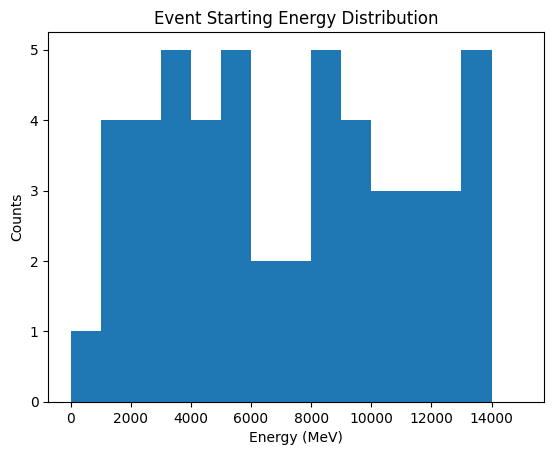

In [3]:
# Open edep-sim file: 
edep_sim_file = "/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/NDLAR_ELECTRON_SAMPLES/CONVERT2H5/electron_NDLAr_10MeVto15GeV_TEST5.1002.CONVERT2H5.hdf5"
#edep_sim_file = "/pscratch/sd/e/ehinkle/nd_ana/sheep_single_shower/ELECTRON_SAMPLES/CONVERT2H5/TEST/electron_positron_10MeVto2GeV.8947.CONVERT2H5.hdf5"
sim_h5 = h5py.File(edep_sim_file, 'r')
event_id = 9
for ev in sim_h5['events']:
    print(ev['E_start'],ev['event_id'])
plt.hist(sim_h5['events']['E_start'], bins=np.linspace(0, 15000, 16))
plt.xlabel('Energy (MeV)')
plt.ylabel('Counts')
plt.title('Event Starting Energy Distribution')

Seg fields: ['event_id', 'vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons']
Trajectorys fields: ['event_id', 'vertex_id', 'traj_id', 'file_traj_id', 'parent_id', 'primary', 'E_start', 'pxyz_start', 'xyz_start', 't_start', 'E_end', 'pxyz_end', 'xyz_end', 't_end', 'pdg_id', 'start_process', 'start_subprocess', 'end_process', 'end_subprocess', 'dist_travel']
Trajectory event IDs: [9]
Segment event IDs: [9]
PDG IDs in segments: [       -11         11         22       2112 1000180380 1000180400]
PDG IDs in trajectories: [       -11         11         22       2112 1000180380 1000180400]
Events: [(9, [0., 0., 0.], 13185.065, [     0.   ,      0.   , -13185.065], 11)]
Number of long segments (dx > 0.37 cm): 83.2
Long segments: [(0,                    0,       0,   -0

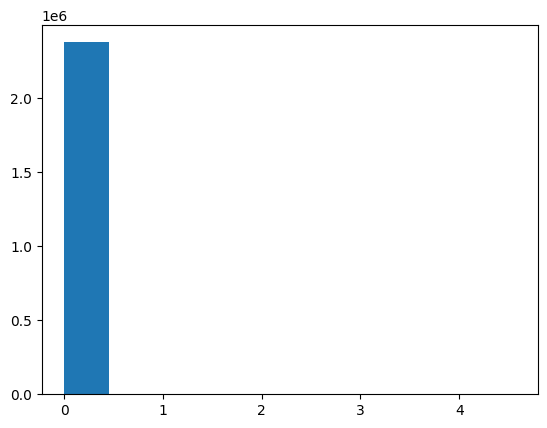

In [29]:
# Look at trajectories dataset for event_id
traj, seg, events = get_shower_data(sim_h5, event_id)

## Filter trajectories for vertex ID
#vert_id_filter = traj['vertex_id'] == vert_id
#traj = traj[vert_id_filter]
#
## Get all EM trajectories
#print("Trajectories fields:", list(traj.dtype.names))
#e_filter = abs(vert_traj['pdg_id']) == 11 
#gamma_filter = vert_traj['pdg_id'] == 22
#em_filter = e_filter | gamma_filter
#em_traj = vert_traj[em_filter]
#print("Trajectories with em_filter:", len(em_traj))
print("Seg fields:", list(seg.dtype.names))
print("Trajectorys fields:", list(traj.dtype.names))
print("Trajectory event IDs:", np.unique(traj['event_id']))
print("Segment event IDs:", np.unique(seg['event_id']))
print("PDG IDs in segments:", np.unique(seg['pdg_id']))
print("PDG IDs in trajectories:", np.unique(traj['pdg_id']))
print("Events:", events)
plt.hist(sim_h5['segments']['dx'])
long_segments_mask = sim_h5['segments']['dx'] > 0.37
long_segments = sim_h5['segments'][long_segments_mask]
print("Number of long segments (dx > 0.37 cm):", len(long_segments)/10)
print("Long segments:", long_segments)
#print("Number of segments:", len(sim_h5['segments']))

Total segment energy: [ 2974.0754  9772.039   5117.545  13075.184   5087.075  12487.97
 12355.044   5735.5376  5517.637   4814.91    1107.636  13816.11
 13702.016  11897.436   8297.166   9152.552   4826.8315  2285.1572
  8520.874   8719.386   4142.524   5349.11    6489.6333 10367.708
  9103.277   7730.385   2709.5154  6558.455   7991.7515   647.2311
 10371.319   9908.44   11317.069   7671.7246 12633.913   3492.522
  8767.906   4250.186  13312.326  13037.765   1387.4425  3234.0547
  1900.3887  3680.025  10634.664   2998.9097  3603.2754  1746.5479
  2953.891  11483.002 ]


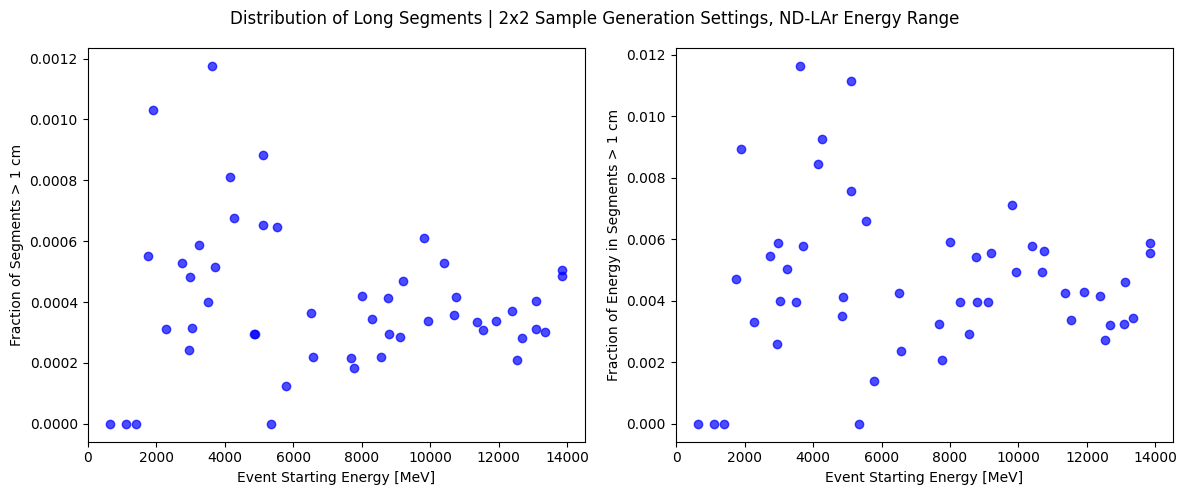

In [4]:
event_energy = []
total_seg_energy = []
total_num_seg = []
num_long_segments = []
long_segments_energy = []

num_events = len(np.unique(sim_h5['events']['event_id']))
for event_id in range(num_events):
    traj, seg, events = get_shower_data(sim_h5, event_id)
    event_energy.append(events['E_start'])
    total_seg_energy.append(np.sum(seg['dE']))
    total_num_seg.append(len(seg))
    long_segments_mask = seg['dx'] > 1
    long_segments = seg[long_segments_mask]
    num_long_segments.append(len(long_segments))
    long_segments_energy.append(np.sum(long_segments['dE']))


event_energy = np.array(event_energy)
total_seg_energy = np.array(total_seg_energy)
print("Total segment energy:", total_seg_energy)
total_num_seg = np.array(total_num_seg)
num_long_segments = np.array(num_long_segments)
long_segments_energy = np.array(long_segments_energy)

frac_long_segments = num_long_segments / total_num_seg
frac_long_segments_energy = long_segments_energy / total_seg_energy

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ax[0].scatter(event_energy, frac_long_segments, color='blue', alpha=0.7)
ax[0].set_xlabel('Event Starting Energy [MeV]')
ax[0].set_ylabel('Fraction of Segments > 1 cm')

ax[1].scatter(event_energy, frac_long_segments_energy, color='blue', alpha=0.7)
ax[1].set_xlabel('Event Starting Energy [MeV]')
ax[1].set_ylabel('Fraction of Energy in Segments > 1 cm')
fig.suptitle('Distribution of Long Segments | 2x2 Sample Generation Settings, ND-LAr Energy Range')
plt.tight_layout()

Shape event energies: (583,)
Shape segment lengths: (583,)


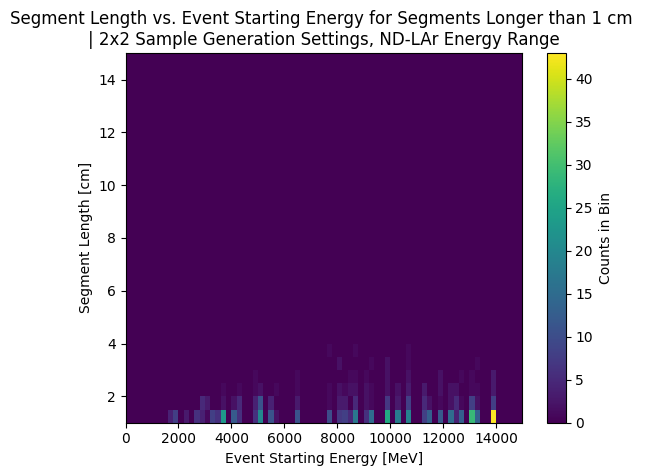

In [5]:
event_energies = []
seg_length = []

num_events = len(np.unique(sim_h5['events']['event_id']))
for event_id in range(num_events):
    traj, seg, events = get_shower_data(sim_h5, event_id)
    ev_E = events['E_start']
    long_segments_mask = seg['dx'] > 1
    long_segments = seg[long_segments_mask]
    for s in long_segments:
        event_energies.append(ev_E[0])
        seg_length.append(s['dx'])  

event_energies = np.array(event_energies)
seg_length = np.array(seg_length)
print("Shape event energies:", event_energies.shape)
print("Shape segment lengths:", seg_length.shape)

plt.hist2d(event_energies, seg_length, bins=[np.linspace(0, 15000, 76), np.linspace(1, 15, 29)])
plt.xlabel('Event Starting Energy [MeV]')
plt.ylabel('Segment Length [cm]')
plt.title('Segment Length vs. Event Starting Energy for Segments Longer than 1 cm \n| 2x2 Sample Generation Settings, ND-LAr Energy Range')
plt.colorbar(label='Counts in Bin')

In [17]:
print("Shape event energies:", event_energies.shape)
print("Shape segment lengths:", seg_length.shape)

Shape event energies: (9259, 1)
Shape segment lengths: (9259,)


[2.9909697e-01 5.7181585e-01 2.4685164e-01 ... 3.1357901e-03 1.5962991e-03
 2.0701102e-04]
2
['event_id', 'vertex_id', 'segment_id', 'z_end', 'traj_id', 'file_traj_id', 'tran_diff', 'z_start', 'x_end', 'y_end', 'n_electrons', 'pdg_id', 'x_start', 'y_start', 't_start', 't0_start', 't0_end', 't0', 'dx', 'long_diff', 'pixel_plane', 't_end', 'dEdx', 'dE', 't', 'y', 'x', 'z', 'n_photons']


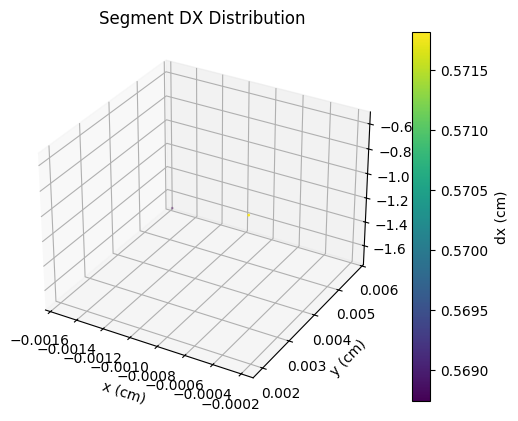

In [53]:
# look at segments for event id = event id
print(seg['dx'])
seg = seg[seg['dx'] > 0.5]
print(len(seg))
print(list(seg.dtype.names))
#plt.scatter(seg['dE'][:100], seg['dx'][:100])
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

shower = ax.scatter(seg['x'], seg['y'], seg['z'], c=seg['dx'], cmap='viridis', s=1)
ax.set_xlabel('x (cm)')
ax.set_ylabel('y (cm)')
ax.set_zlabel('z (cm)')
ax.set_title('Segment DX Distribution')
plt.colorbar(shower, ax=ax, label='dx (cm)')
plt.show()


# PLOTLY VERSION: FOR SEGMENTS
# Create an empty figure
fig = go.Figure()

# Loop through segments
for segment in seg:

    # Extract coordinates
    x = [segment['x_start'], segment['x_end']]
    y = [segment['y_start'], segment['y_end']]
    z = [segment['z_start'], segment['z_end']]

    # Add the trajectory to the plot
    fig.add_trace(go.Scatter3d(
        x=z,  # Z-axis in matplotlib corresponds to x-axis in plotly
        y=x,  # X-axis in matplotlib corresponds to y-axis in plotly
        z=y,  # Y-axis in matplotlib corresponds to z-axis in plotly
        mode='lines+markers',
        marker=dict(size=1),
        line=dict(color='blue', width=1, dash='solid'),
        name=f"Trajectory {segment['traj_id']},  # Use traj_id for naming"
    ))

# Set axis labels and limits
fig.update_layout(
    scene=dict(
        xaxis_title='Z',
        yaxis_title='X',
        zaxis_title='Y',
        #xaxis=dict(range=[-300, 300]),
        #yaxis=dict(range=[-300, 300]),
        #zaxis=dict(range=[-300, 300]),
    ),
    width=1000,  # Set the width of the plot (in pixels)
    height=1000,  # Set the height of the plot (in pixels)
    showlegend=False  # Set to True if you want to display the legend
)

# Show the plot
fig.show()

# PLOTLY VERSION: 
# Create an empty figure
fig = go.Figure()

# Loop through each trajectory in em_traj
for tid in traj['traj_id']:


    single_traj = traj[traj['traj_id'] == tid]

    if single_traj['pdg_id'] == 22:
        pdg_color = 'orange'
    elif abs(single_traj['pdg_id']) == 11:
        pdg_color = 'blue'
    else:
        pdg_color = 'black'

    xyz_start = single_traj['xyz_start'][0]
    xyz_end = single_traj['xyz_end'][0]

    # Extract coordinates
    x = [xyz_start[0], xyz_end[0]]
    y = [xyz_start[1], xyz_end[1]]
    z = [xyz_start[2], xyz_end[2]]

    # Add the trajectory to the plot
    fig.add_trace(go.Scatter3d(
        x=z,  # Z-axis in matplotlib corresponds to x-axis in plotly
        y=x,  # X-axis in matplotlib corresponds to y-axis in plotly
        z=y,  # Y-axis in matplotlib corresponds to z-axis in plotly
        mode='lines+markers',
        marker=dict(size=1),
        line=dict(color=pdg_color, width=2, dash='dash'),
        name=f"Trajectory {tid}"
    ))

# Set axis labels and limits
fig.update_layout(
    scene=dict(
        xaxis_title='Z',
        yaxis_title='X',
        zaxis_title='Y',
        #xaxis=dict(range=[-65, 65]),
        #yaxis=dict(range=[-65, 65]),
        #zaxis=dict(range=[-65, 65]),
    ),
    width=1000,  # Set the width of the plot (in pixels)
    height=1000,  # Set the height of the plot (in pixels)
    showlegend=False  # Set to True if you want to display the legend
)

# Show the plot
fig.show()

In [23]:
# Select trajectory id
traj_id = 9
# Get vertex associated trajectories
vertex_assoc_traj = traj[traj['vertex_id'] == vert_id]
# Get the trajectory associated with the selected traj_id   
selected_traj = vertex_assoc_traj[vertex_assoc_traj['traj_id'] == traj_id]
children_traj = vertex_assoc_traj[vertex_assoc_traj['parent_id'] == traj_id]
print("Children Trajectories:", children_traj['traj_id'])
print("Trajectory PDG ID:", selected_traj['pdg_id'])
print("Selected Trajectory:", selected_traj)
print("Trajectory information:", selected_traj.dtype.names)
print("Trajectory start process:", selected_traj['start_process'])
print("Trajectory start subprocess:", selected_traj['start_subprocess'])
print("Trajectory end process:", selected_traj['end_process'])
print("Trajectory end process:", selected_traj['end_subprocess'])
print("Trajectory parent trajectory ID:", selected_traj['parent_id'])

NameError: name 'vert_id' is not defined